## SETUP

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sys.path.append(os.path.abspath("../"))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## DATA LOADING 

In [4]:
import os
import pandas as pd

COLUMN_NAMES = [
    "TransactionId", "BatchId", "AccountId", "SubscriptionId", "CustomerId",
    "CurrencyCode", "CountryCode", "ProviderId", "ProductId", "ProductCategory",
    "ChannelId", "Amount", "Value", "TransactionStartTime", "PricingStrategy", "FraudResult"
]

def load_raw_data(file_path: str) -> pd.DataFrame:
    """
    Loads the Xente Fraud Detection dataset.
    Ensures correct header mapping and automatically parses date string columns.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The dataset file could not be found at: '{file_path}'")
        
    try:
        # 💡 Fixed: Removed 'infer_datetime_format=True' to comply with pandas 2.0+
        df = pd.read_csv(
            file_path, 
            sep=',', 
            parse_dates=['TransactionStartTime']
        )
        return df
        
    except Exception as e:
        raise IOError(f"Failed to cleanly load the Xente CSV. Details: {e}")
    df.head()


In [5]:
import os
import pandas as pd

COLUMN_NAMES = [
    "TransactionId", "BatchId", "AccountId", "SubscriptionId", "CustomerId",
    "CurrencyCode", "CountryCode", "ProviderId", "ProductId", "ProductCategory",
    "ChannelId", "Amount", "Value", "TransactionStartTime", "PricingStrategy", "FraudResult"
]

def load_raw_data(file_path: str) -> pd.DataFrame:
    """
    Loads the Xente Fraud Detection dataset.
    Ensures correct header mapping and automatically parses date string columns.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The dataset file could not be found at: '{file_path}'")
        
    try:
        # 💡 Fixed: Removed 'infer_datetime_format=True' to comply with pandas 2.0+
        df = pd.read_csv(
            file_path, 
            sep=',', 
            parse_dates=['TransactionStartTime']
        )
        return df
        
    except Exception as e:
        raise IOError(f"Failed to cleanly load the Xente CSV. Details: {e}")


In [6]:
import pandas as pd

# Use your actual notebook variable 'raw_data_path'
raw_data_path = "../data/raw/data.csv"

df = pd.read_csv(
    raw_data_path, 
    sep=',', 
    parse_dates=['TransactionStartTime']
)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   TransactionId         95662 non-null  str                
 1   BatchId               95662 non-null  str                
 2   AccountId             95662 non-null  str                
 3   SubscriptionId        95662 non-null  str                
 4   CustomerId            95662 non-null  str                
 5   CurrencyCode          95662 non-null  str                
 6   CountryCode           95662 non-null  int64              
 7   ProviderId            95662 non-null  str                
 8   ProductId             95662 non-null  str                
 9   ProductCategory       95662 non-null  str                
 10  ChannelId             95662 non-null  str                
 11  Amount                95662 non-null  float64            
 12  Value          

## EDA 

In [7]:
# stat for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


### Target Variable Distribution (Class Imbalance)

In [8]:
# Good (0) vs Bad (1) credit risk
default_counts = df['default'].value_counts()
default_rates = df['default'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=default_counts.index, y=default_counts.values, hue=default_counts.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Distribution of Defaults')
ax.set_xlabel('Default State (0=Good, 1=Bad)')
ax.set_ylabel('Count')

for i, count in enumerate(default_counts):
    pct = default_rates.iloc[i] * 100
    ax.annotate(f"{count} ({pct:.1f}%)", xy=(i, count + 15), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

KeyError: 'default'

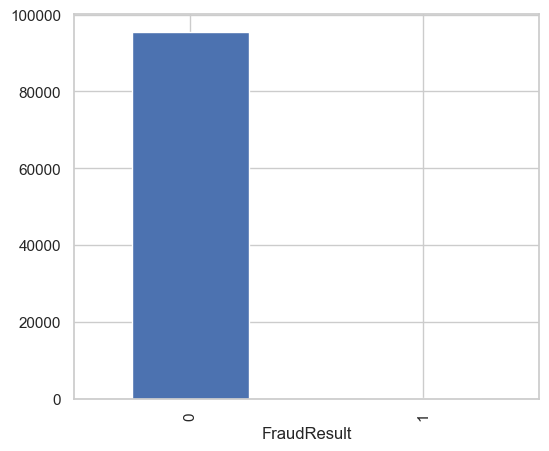

In [9]:
import matplotlib.pyplot as plt

# Replace 'default' with 'FraudResult'
default_counts = df['FraudResult'].value_counts()
default_rates = df['FraudResult'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(6, 5))
default_counts.plot(kind='bar', ax=ax)
plt.show()


### Numerical Features Distributions

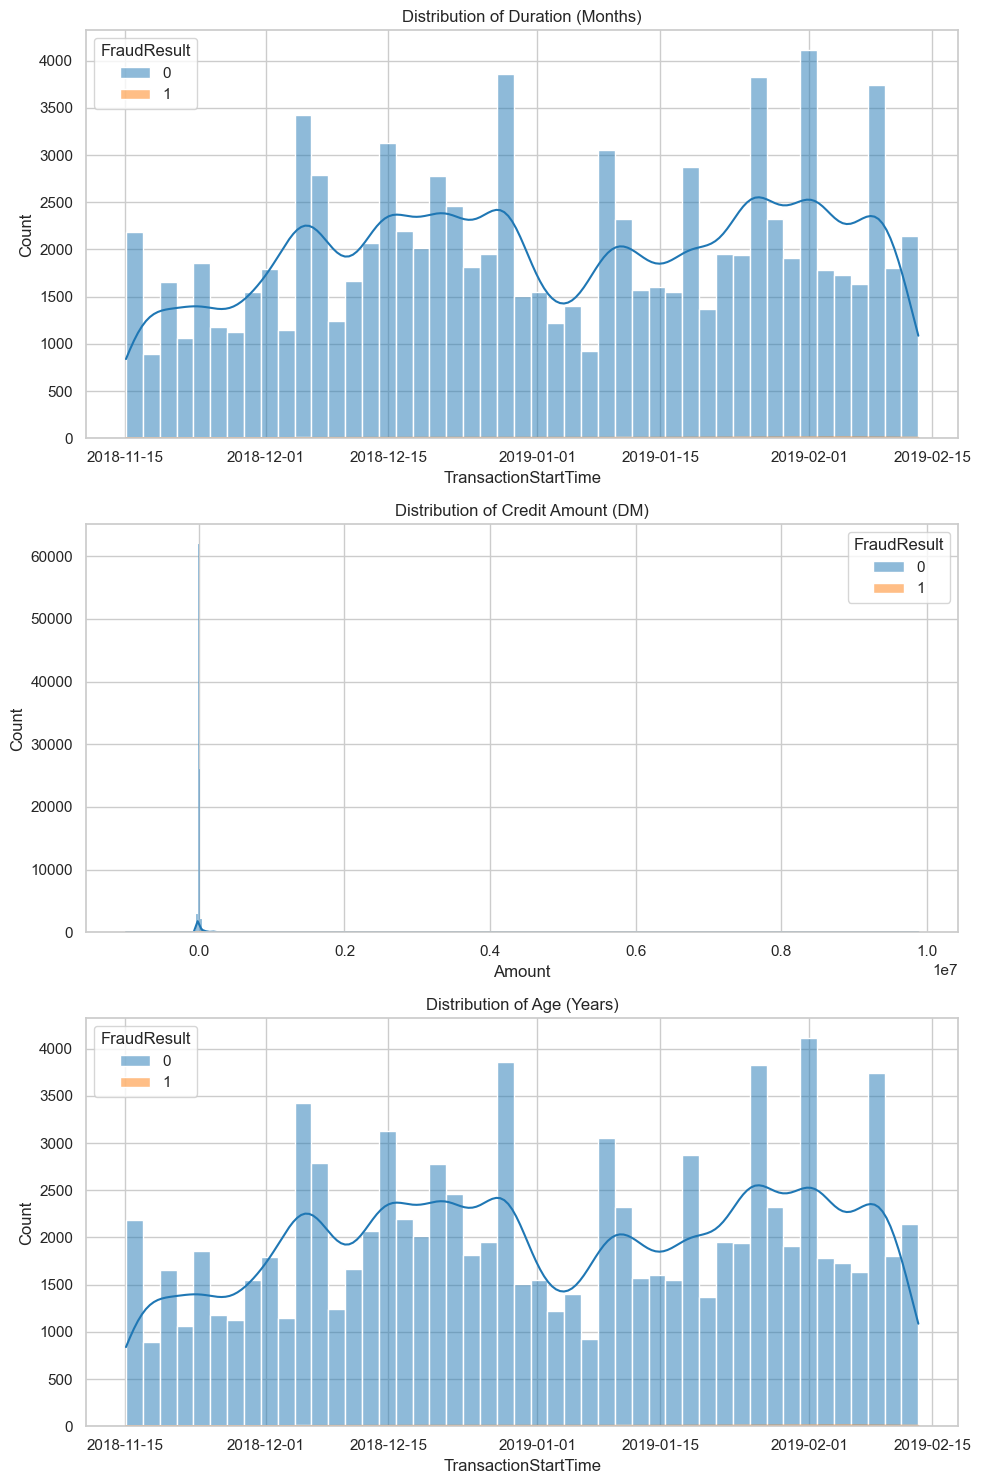

In [10]:

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Duration Months
sns.histplot(data=df, x='TransactionStartTime', hue='FraudResult', kde=True, multiple='stack', palette='tab10', ax=axes[0])
axes[0].set_title('Distribution of Duration (Months)')

# Credit Amount
sns.histplot(data=df, x='Amount', hue='FraudResult', kde=True, multiple='stack', palette='tab10', ax=axes[1])
axes[1].set_title('Distribution of Credit Amount (DM)')

# Age
sns.histplot(data=df, x='TransactionStartTime', hue='FraudResult', kde=True, multiple='stack', palette='tab10', ax=axes[2])
axes[2].set_title('Distribution of Age (Years)')

plt.tight_layout()
plt.show()

### Categorical Features Analysis

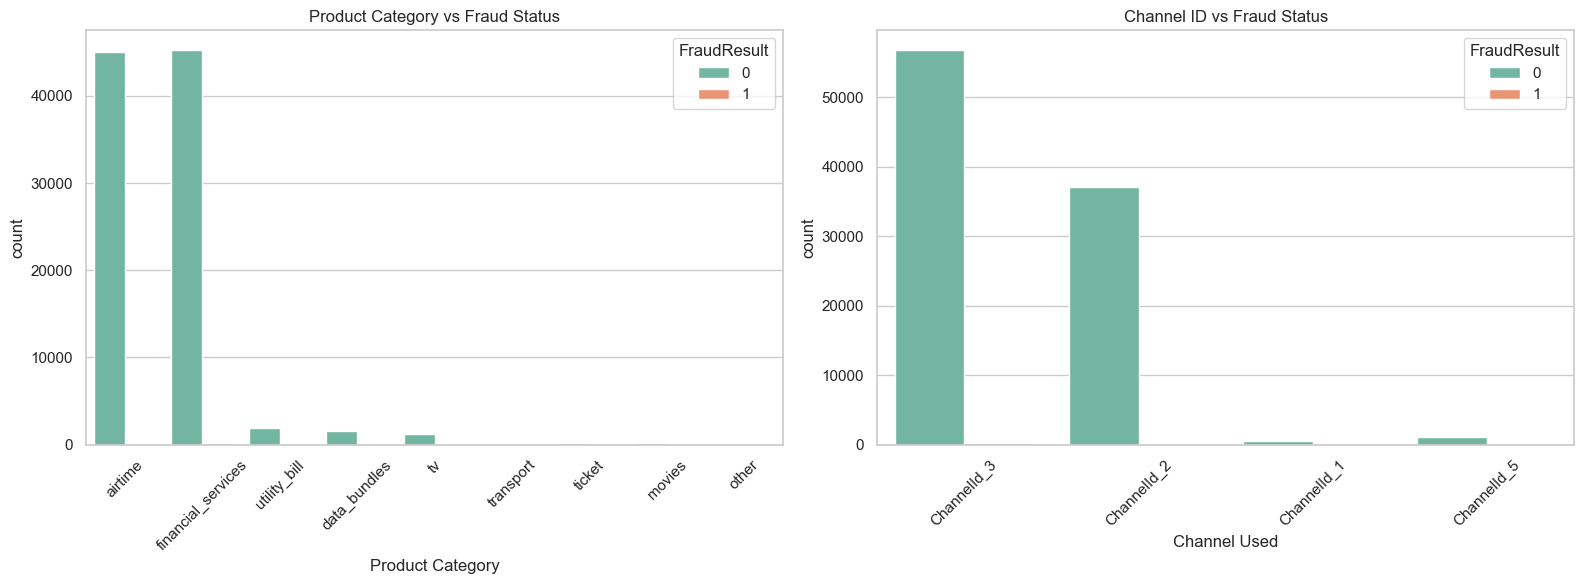

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setup a 1-row, 2-column subplot canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Product Category breakdown split by Fraud Status
sns.countplot(data=df, x='ProductCategory', hue='FraudResult', palette='Set2', ax=axes[0])
axes[0].set_title('Product Category vs Fraud Status')
axes[0].set_xlabel('Product Category')
axes[0].tick_params(axis='x', rotation=45) # Rotates labels to prevent overlap

# Right Plot: Channel ID breakdown split by Fraud Status
sns.countplot(data=df, x='ChannelId', hue='FraudResult', palette='Set2', ax=axes[1])
axes[1].set_title('Channel ID vs Fraud Status')
axes[1].set_xlabel('Channel Used')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Outlier Detection and Capping

In [12]:
import numpy as np

def cap_outliers(df, column):
    """Caps numerical outliers using the Interquartile Range (IQR) method."""
    df_capped = df.copy()
    Q1 = df_capped[column].quantile(0.25)
    Q3 = df_capped[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values outside the boundaries
    df_capped[column] = np.clip(df_capped[column], lower_bound, upper_bound)
    return df_capped

# Apply the capping function to your Amount column
df_capped = cap_outliers(df, 'Amount')


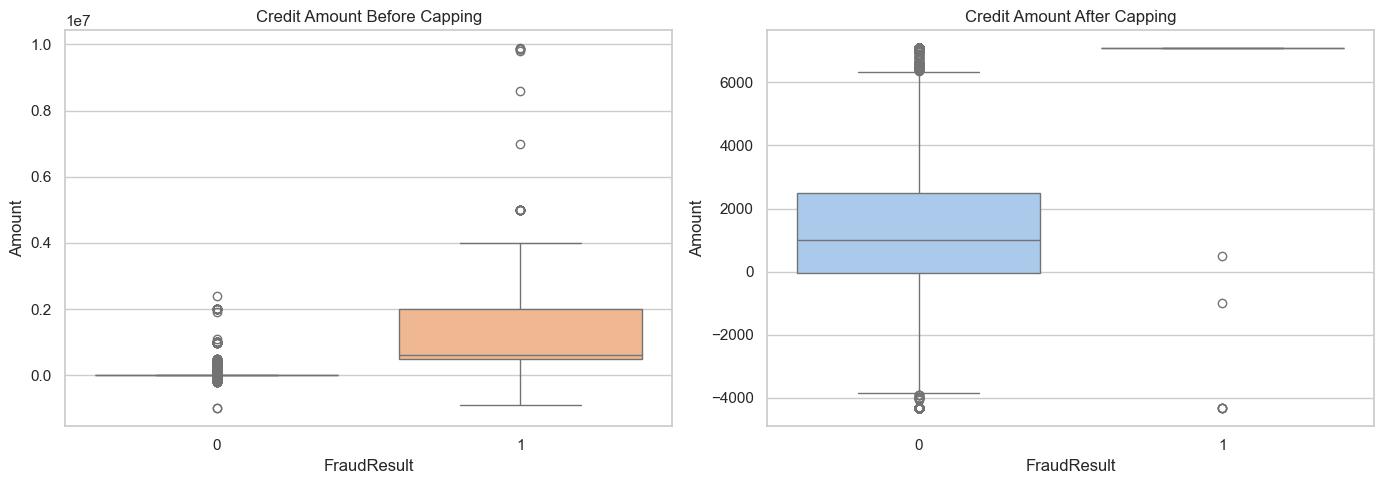

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='FraudResult', y='Amount', hue='FraudResult', palette='pastel', legend=False, ax=axes[0])
axes[0].set_title('Credit Amount Before Capping')

sns.boxplot(data=df_capped, x='FraudResult', y='Amount', hue='FraudResult', palette='pastel', legend=False, ax=axes[1])
axes[1].set_title('Credit Amount After Capping')

plt.tight_layout()
plt.show()